# Notebook 6 - Training and evaluation

Reads the feature tables and `05_transformers.joblib`, writes `06_model.joblib` and
`06_results.md`.

`05_features_test.parquet` is not read before section 8, and then once, after every decision is
fixed. Going back afterwards would turn the test set into a second validation set.

Order of work: baselines, then the advanced models, then tuning on validation, then a threshold,
then one measurement on test.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve, accuracy_score)

ARTIFACTS = Path("..") / "artifacts"
FIGURES   = Path("..") / "figures"
plt.rcParams["figure.dpi"] = 110

transformers = joblib.load(ARTIFACTS / "05_transformers.joblib")
FEATURES = transformers["feature_columns"]
scaler   = transformers["scaler"]

train = pd.read_parquet(ARTIFACTS / "05_features_train.parquet")
val   = pd.read_parquet(ARTIFACTS / "05_features_val.parquet")
# LOCKED: the test set is not loaded here. Section 8 only.

X_train, y_train = train[FEATURES], train["is_late"].astype(int)
X_val,   y_val   = val[FEATURES],   val["is_late"].astype(int)

print(f"train {X_train.shape}   late rate {100*y_train.mean():.2f}%")
print(f"val   {X_val.shape}   late rate {100*y_val.mean():.2f}%")
print(f"\n{len(FEATURES)} features")

train (64320, 31)   late rate 7.95%
val   (13547, 31)   late rate 5.53%

31 features


## 1. Metrics

The validation late rate is 5.5%, so "nothing is late" scores 94.5% accuracy while catching
nothing. That makes accuracy misleading here.

| Metric | Role |
|---|---|
| PR-AUC | primary - concentrates on the positive class |
| ROC-AUC | ranking quality, comparable across splits with different base rates |
| recall @ alert budget | what it means operationally: acting on the riskiest 5%, how many late orders are caught |

In [2]:
ALERT_BUDGET = 0.05   # the assumed operational capacity: intervene on the riskiest 5%

def recall_at_budget(y_true, score, budget=ALERT_BUDGET):
    '''If we alerted on the top budget% of orders, how many late ones do we catch and at what precision?'''
    k = int(len(score) * budget)
    top = np.argsort(-np.asarray(score))[:k]
    y_true = np.asarray(y_true)
    recall    = y_true[top].sum() / y_true.sum()
    precision = y_true[top].mean()
    return recall, precision, precision / y_true.mean()   # the last one: the lift

def evaluate(name, y_true, score):
    recall, precision, lift = recall_at_budget(y_true, score)
    return {
        "model": name,
        "ROC-AUC": round(roc_auc_score(y_true, score), 4),
        "PR-AUC":  round(average_precision_score(y_true, score), 4),
        f"recall@{int(100*ALERT_BUDGET)}%":    round(100*recall, 1),
        f"precision@{int(100*ALERT_BUDGET)}%": round(100*precision, 1),
        "lift": round(lift, 2),
    }

results = []

## 2. Baselines

Three levels, from the trivial to the reasonable, so that later numbers mean something.

In [3]:
# baseline zero: "nothing is late" - to expose the accuracy trap
trivial_pred = np.zeros(len(y_val))
print(f"The 'nothing is late' model:")
print(f"  accuracy : {100*accuracy_score(y_val, trivial_pred):.2f}%   <- a number that looks excellent")
print(f"  late orders caught: 0 out of {y_val.sum():,}   <- and it is worthless")

The 'nothing is late' model:
  accuracy : 94.47%   <- a number that looks excellent
  late orders caught: 0 out of 749   <- and it is worthless


In [4]:
# baseline 1: the strongest feature the EDA found, on its own, with no learning at all
# (negated because a generous promise means a lower chance of lateness)
results.append(evaluate("B1: promise_per_100km alone", y_val, -X_val["promise_per_100km"]))

# baseline 2: logistic regression on all features - a simple but real model
X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)

logreg = LogisticRegression(C=1.0, max_iter=3000, class_weight="balanced", random_state=42)
logreg.fit(X_train_scaled, y_train)
results.append(evaluate("B2: logistic regression", y_val, logreg.predict_proba(X_val_scaled)[:, 1]))

pd.DataFrame(results).set_index("model")

,ROC-AUC,PR-AUC,recall@5%,precision@5%,lift
model,,,,,
B1: promise_per_100km alone,0.6953,0.1433,17.5,19.4,3.50
B2: logistic regression,0.7739,0.1709,20.7,22.9,4.14


## 3. Trees

Notebook 4 expected these to win, on the non-monotonic `promised_days` relationship, the skew and
the interactions.

The built-in `early_stopping` is disabled: it carves a random slice out of train, and on
non-stationary temporal data that gives an optimistic estimate and stops at the wrong point. The
iteration count is tuned on the real validation set instead.

In [5]:
forest = RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                class_weight="balanced", n_jobs=-1, random_state=42)
forest.fit(X_train, y_train)
results.append(evaluate("M1: Random Forest", y_val, forest.predict_proba(X_val)[:, 1]))

pd.DataFrame(results).set_index("model")

,ROC-AUC,PR-AUC,recall@5%,precision@5%,lift
model,,,,,
B1: promise_per_100km alone,0.6953,0.1433,17.5,19.4,3.50
B2: logistic regression,0.7739,0.1709,20.7,22.9,4.14
M1: Random Forest,0.7303,0.1490,19.2,21.3,3.85


In [6]:
grid = []
for n_iter in (60, 120, 200, 300):
    for max_leaves in (15, 31):
        model = HistGradientBoostingClassifier(
            learning_rate=0.05, max_leaf_nodes=max_leaves, max_iter=n_iter,
            l2_regularization=1.0, min_samples_leaf=40,
            early_stopping=False, class_weight="balanced", random_state=42)
        model.fit(X_train, y_train)
        score = model.predict_proba(X_val)[:, 1]
        grid.append({"max_iter": n_iter, "max_leaf_nodes": max_leaves,
                     "ROC-AUC": round(roc_auc_score(y_val, score), 4),
                     "PR-AUC":  round(average_precision_score(y_val, score), 4)})

grid_df = pd.DataFrame(grid)
grid_df.sort_values("PR-AUC", ascending=False).head(8)

,max_iter,max_leaf_nodes,ROC-AUC,PR-AUC
2,120,15,0.7502,0.1681
0,60,15,0.7486,0.1653
4,200,15,0.7459,0.1651
3,120,31,0.7430,0.1649
1,60,31,0.7470,0.1638
6,300,15,0.7430,0.1611
5,200,31,0.7353,0.1579
7,300,31,0.7297,0.1531


### Boosting rounds against validation score

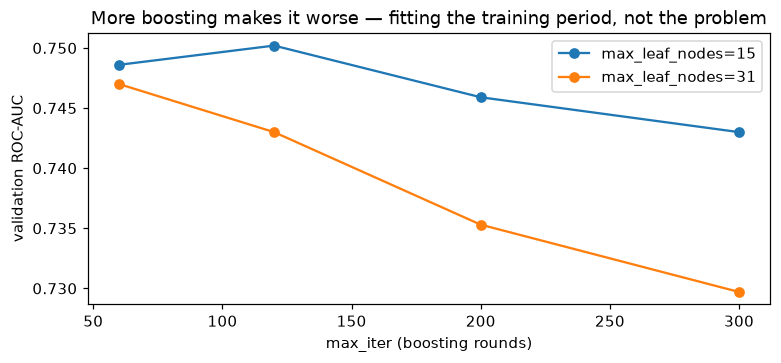

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.2))
for leaves, g in grid_df.groupby("max_leaf_nodes"):
    ax.plot(g["max_iter"], g["ROC-AUC"], marker="o", label=f"max_leaf_nodes={leaves}")
ax.set_xlabel("max_iter (boosting rounds)")
ax.set_ylabel("validation ROC-AUC")
ax.set_title("More boosting makes it worse — fitting the training period, not the problem")
ax.legend()
plt.savefig(FIGURES / "09_boosting_overfit.png", bbox_inches="tight", dpi=130)
plt.show()

In [8]:
# shallow trees with strong regularisation - a last attempt to be fair to the trees
depth_results = []
for max_depth in (2, 3, 4):
    model = HistGradientBoostingClassifier(
        learning_rate=0.05, max_depth=max_depth, max_iter=300,
        l2_regularization=5.0, min_samples_leaf=100,
        early_stopping=False, class_weight="balanced", random_state=42)
    model.fit(X_train, y_train)
    score = model.predict_proba(X_val)[:, 1]
    depth_results.append({"max_depth": max_depth,
                          "ROC-AUC": round(roc_auc_score(y_val, score), 4),
                          "PR-AUC":  round(average_precision_score(y_val, score), 4)})
    if max_depth == 2:
        best_tree, best_tree_score = model, score

pd.DataFrame(depth_results)

,max_depth,ROC-AUC,PR-AUC
0,2,0.7526,0.1709
1,3,0.7523,0.1685
2,4,0.7488,0.1623


In [9]:
results.append(evaluate("M2: Gradient Boosting (depth=2)", y_val, best_tree_score))
pd.DataFrame(results).set_index("model")

,ROC-AUC,PR-AUC,recall@5%,precision@5%,lift
model,,,,,
B1: promise_per_100km alone,0.6953,0.1433,17.5,19.4,3.50
B2: logistic regression,0.7739,0.1709,20.7,22.9,4.14
M1: Random Forest,0.7303,0.1490,19.2,21.3,3.85
M2: Gradient Boosting (depth=2),0.7526,0.1709,19.4,21.4,3.87


## 4. The trees lost

Logistic regression came out ahead, against the notebook 4 expectation.

Three plausible reasons. The feature engineering had already handled the non-linearity - target
encoding produces monotonic numbers by construction, and `promise_per_100km` covers the
promise/distance interaction, so little was left to discover. The base rate moves (7.95% train
against 5.53% validation), and a flexible model captures the training period precisely while a
constrained one transfers better. And the plot above shows validation score falling as boosting
rounds increase, which is memorisation rather than undertraining.

## 5. Tuning

Regularisation strength `C` on validation.

In [10]:
tuning = []
for C in (0.01, 0.03, 0.1, 0.3, 1.0, 3.0):
    model = LogisticRegression(C=C, max_iter=3000, class_weight="balanced", random_state=42)
    model.fit(X_train_scaled, y_train)
    score = model.predict_proba(X_val_scaled)[:, 1]
    tuning.append({"C": C,
                   "ROC-AUC": round(roc_auc_score(y_val, score), 4),
                   "PR-AUC":  round(average_precision_score(y_val, score), 4)})

tuning_df = pd.DataFrame(tuning).set_index("C")
tuning_df

,ROC-AUC,PR-AUC
C,,
0.01,0.7732,0.1702
0.03,0.7737,0.1706
0.10,0.7738,0.1708
0.30,0.7739,0.1709
1.00,0.7739,0.1709
3.00,0.7739,0.1709


In [11]:
best_C = float(tuning_df["PR-AUC"].idxmax())
final_model = LogisticRegression(C=best_C, max_iter=3000,
                                 class_weight="balanced", random_state=42)
final_model.fit(X_train_scaled, y_train)
val_score = final_model.predict_proba(X_val_scaled)[:, 1]

print(f"Final model: logistic regression, C = {best_C}")
print(f"validation ROC-AUC = {roc_auc_score(y_val, val_score):.4f}")
print(f"validation PR-AUC  = {average_precision_score(y_val, val_score):.4f}")
print("\nThe result is flat across the C values - the performance comes from the features, not from tuning the model.")

Final model: logistic regression, C = 0.3
validation ROC-AUC = 0.7739
validation PR-AUC  = 0.1709

The result is flat across the C values - the performance comes from the features, not from tuning the model.


## 6. Feature importance

Permutation importance on validation: shuffle one column and measure the drop. It shows what the
model actually uses.

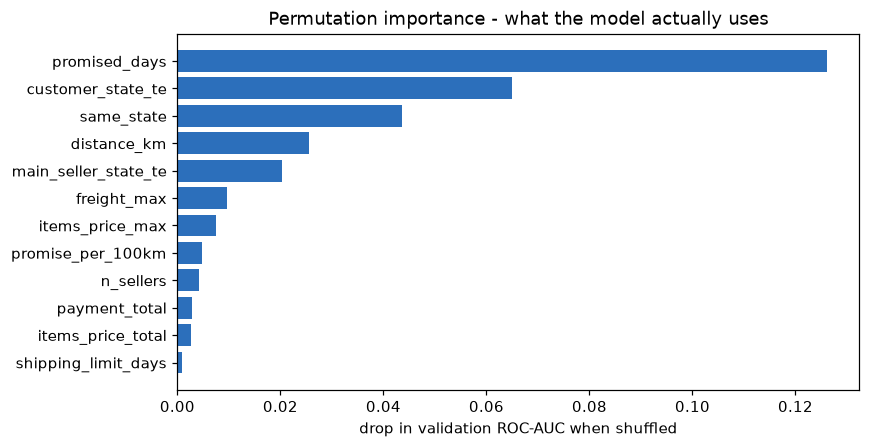

,importance
promised_days,0.1261
customer_state_te,0.0649
same_state,0.0436
distance_km,0.0255
main_seller_state_te,0.0202
freight_max,0.0096
items_price_max,0.0074
promise_per_100km,0.0048


In [12]:
perm = permutation_importance(final_model, X_val_scaled, y_val,
                              scoring="roc_auc", n_repeats=5,
                              random_state=42, n_jobs=-1)

importance = (pd.Series(perm.importances_mean, index=FEATURES)
                .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 4.2))
top = importance.head(12).iloc[::-1]
ax.barh(top.index, top.values, color="#2c6fbb")
ax.set_xlabel("drop in validation ROC-AUC when shuffled")
ax.set_title("Permutation importance - what the model actually uses")
plt.savefig(FIGURES / "10_feature_importance.png", bbox_inches="tight", dpi=130)
plt.show()

importance.head(8).round(4).to_frame("importance")

`promised_days` comes out first, although notebook 4 measured it alone at AUC 0.487, while
`promise_per_100km` - the EDA's strongest single column - barely registers.

Univariate strength is not importance inside a model. The promise was masked by distance
(correlated 0.65): long promises go to long distances, so the effects cancel when the promise is
looked at alone. With both columns present the model can ask whether this promise is enough for
this distance, and the effect appears.

That also explains `promise_per_100km` here - it is a fixed ratio between two variables the model
already holds separately, so it can build something better. It was needed to see the phenomenon,
not to represent it.

The rest of the ranking matches the EDA: customer state, same state, distance.

## 7. Threshold and alert budget

The model outputs a risk score; the operating threshold comes from capacity - how many orders the
team can act on.

In [13]:
budgets = [0.02, 0.05, 0.10, 0.20, 0.30]
rows = []
for b in budgets:
    recall, precision, lift = recall_at_budget(y_val, val_score, b)
    rows.append({"alert budget": f"{int(100*b)}%",
                 "orders flagged": int(len(val_score)*b),
                 "recall %": round(100*recall, 1),
                 "precision %": round(100*precision, 1),
                 "lift": round(lift, 2)})

budget_df = pd.DataFrame(rows).set_index("alert budget")
budget_df

,orders flagged,recall %,precision %,lift
alert budget,,,,
2%,270,8.4,23.3,4.22
5%,677,20.7,22.9,4.14
10%,1354,35.8,19.8,3.58
20%,2709,55.7,15.4,2.78
30%,4064,69.0,12.7,2.30


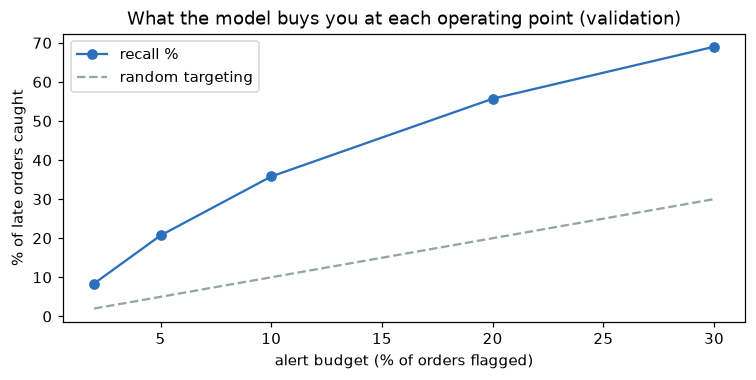

In [14]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot([100*b for b in budgets], budget_df["recall %"], marker="o",
        color="#2c6fbb", label="recall %")
ax.plot([100*b for b in budgets], [100*b for b in budgets], "--",
        color="#95a5a6", label="random targeting")
ax.set_xlabel("alert budget (% of orders flagged)")
ax.set_ylabel("% of late orders caught")
ax.set_title("What the model buys you at each operating point (validation)")
ax.legend()
plt.savefig(FIGURES / "11_alert_budget.png", bbox_inches="tight", dpi=130)
plt.show()

At a 5% budget the model catches about 21% of the delays, four times random targeting; at 20% it
catches more than half.

The threshold is tuned at a 5.53% base rate. The test base rate is different, so what carries over
is the budget percentage, not the numeric cut - the warning from notebook 3.

## 8. Test

Features, model, regularisation and threshold are all fixed. The test set is opened once here and
nothing is changed afterwards.

In [15]:
test = pd.read_parquet(ARTIFACTS / "05_features_test.parquet")
X_test, y_test = test[FEATURES], test["is_late"].astype(int)
X_test_scaled = scaler.transform(X_test)

test_score = final_model.predict_proba(X_test_scaled)[:, 1]

print(f"test: {len(test):,} orders, late rate {100*y_test.mean():.2f}%")
print(f"(for comparison - train {100*y_train.mean():.2f}%  |  val {100*y_val.mean():.2f}%)")

test: 18,603 orders, late rate 3.61%
(for comparison - train 7.95%  |  val 5.53%)


In [16]:
final_comparison = pd.DataFrame([
    evaluate("validation", y_val,  val_score),
    evaluate("test",       y_test, test_score),
]).set_index("model")

final_comparison

,ROC-AUC,PR-AUC,recall@5%,precision@5%,lift
model,,,,,
validation,0.7739,0.1709,20.7,22.9,4.14
test,0.7107,0.0849,15.0,10.9,3.01


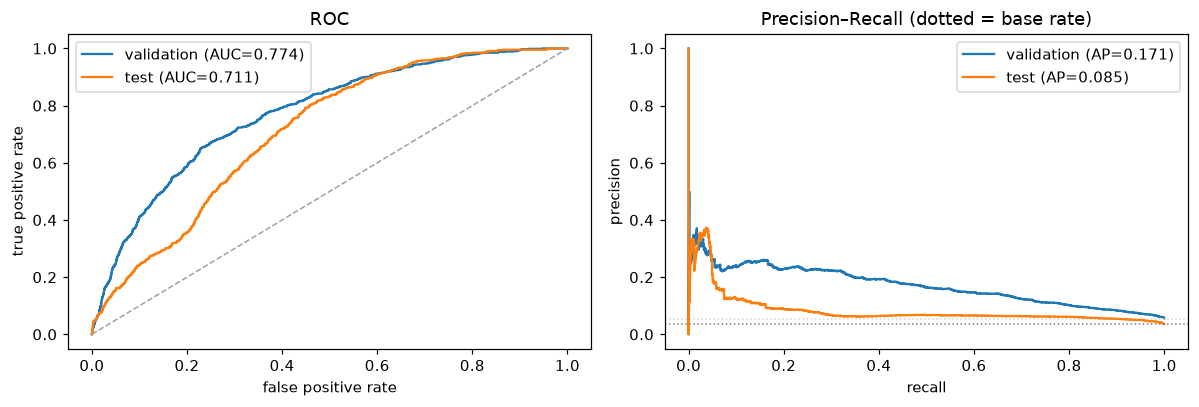

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for name, y_true, score in [("validation", y_val, val_score), ("test", y_test, test_score)]:
    fpr, tpr, _ = roc_curve(y_true, score)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_true, score):.3f})")
    precision, recall, _ = precision_recall_curve(y_true, score)
    axes[1].plot(recall, precision, label=f"{name} (AP={average_precision_score(y_true, score):.3f})")
    axes[1].axhline(y_true.mean(), linestyle=":", linewidth=1,
                    color="gray" if name == "test" else "lightgray")

axes[0].plot([0, 1], [0, 1], "--", color="#95a5a6", linewidth=1)
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC"); axes[0].legend()
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("Precision–Recall (dotted = base rate)"); axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / "12_final_curves.png", bbox_inches="tight", dpi=130)
plt.show()

In [18]:
test_budget = []
for b in budgets:
    recall, precision, lift = recall_at_budget(y_test, test_score, b)
    test_budget.append({"budget": f"{int(100*b)}%",
                        "recall %": round(100*recall, 1),
                        "precision %": round(100*precision, 1),
                        "lift": round(lift, 2)})
pd.DataFrame(test_budget).set_index("budget")

,recall %,precision %,lift
budget,,,
2%,7.4,13.4,3.72
5%,15.0,10.9,3.01
10%,24.0,8.7,2.40
20%,35.1,6.3,1.76
30%,55.2,6.6,1.84


### Reading the validation-test gap

The late rate falls from 5.53% to 3.61% between the two splits, and the metrics respond differently.
ROC-AUC is a ranking metric and is not driven by the base rate, so comparing it across splits is
fair. PR-AUC is: a rarer positive class lowers the achievable ceiling, so its drop is expected.
Precision at a fixed budget falls for the same reason, while lift stays comparable.

ROC-AUC still fell from 0.774 to 0.711, and since it is a ranking metric that drop is a real loss
of generalisation rather than an artefact. The likely cause is distance in time: training ends in
March 2018 and the test period runs June to August, three to five months past anything the model
has seen, in data that is not stationary.

It remains useful - 3.0x lift on unseen data and ROC-AUC above the 0.679 from Task 1 - but a model
like this needs periodic retraining.

## 9. Saving

In [19]:
model_bundle = {
    "model": final_model,
    "model_type": "LogisticRegression",
    "hyperparameters": {"C": best_C, "class_weight": "balanced", "max_iter": 3000},
    "features": FEATURES,
    "requires_scaling": True,
    "scaler_source": "05_transformers.joblib -> transformers['scaler']",
    "target": "is_late",
    "label_definition": "calendar-day rule (notebook 2)",
    "alert_budget": ALERT_BUDGET,
    "metrics": {
        "validation": evaluate("validation", y_val, val_score),
        "test":       evaluate("test", y_test, test_score),
    },
    "base_rates": {
        "train": float(y_train.mean()),
        "val":   float(y_val.mean()),
        "test":  float(y_test.mean()),
    },
}

path = ARTIFACTS / "06_model.joblib"
joblib.dump(model_bundle, path)
print(f"saved: {path.name}  ({path.stat().st_size/1024:.0f} KB)")

saved: 06_model.joblib  (2 KB)


In [20]:
val_metrics  = model_bundle["metrics"]["validation"]
test_metrics = model_bundle["metrics"]["test"]
b1 = results[0]

summary = f'''# Model results - notebook 6

**Final model:** logistic regression (C={best_C}, class_weight="balanced")
on {len(FEATURES)} features, trained on {len(train):,} orders (up to 2018-03-31).
**Label:** the calendar-day rule (notebook 2).

## Results

| | validation | test |
|---|---|---|
| orders | {len(val):,} | {len(test):,} |
| late rate | {100*y_val.mean():.2f}% | {100*y_test.mean():.2f}% |
| **ROC-AUC** | **{val_metrics["ROC-AUC"]}** | **{test_metrics["ROC-AUC"]}** |
| PR-AUC | {val_metrics["PR-AUC"]} | {test_metrics["PR-AUC"]} |
| recall @ 5% | {val_metrics["recall@5%"]}% | {test_metrics["recall@5%"]}% |
| lift @ 5% | {val_metrics["lift"]}x | {test_metrics["lift"]}x |

The test set was opened once, after every decision had been fixed.

## Comparison against the baselines (on validation)

| Model | ROC-AUC | PR-AUC |
|---|---|---|
| "nothing is late" | - (accuracy {100*(1-y_val.mean()):.1f}% with no usefulness at all) | - |
| {b1["model"]} | {b1["ROC-AUC"]} | {b1["PR-AUC"]} |
| Random Forest | {results[2]["ROC-AUC"]} | {results[2]["PR-AUC"]} |
| Gradient Boosting (depth=2) | {results[3]["ROC-AUC"]} | {results[3]["PR-AUC"]} |
| **logistic regression (winner)** | **{val_metrics["ROC-AUC"]}** | **{val_metrics["PR-AUC"]}** |

The Task 1 reference (purchase-time features, a different label and split): ROC-AUC = 0.679.

## Top five features (permutation importance on validation)

{importance.head(5).round(4).to_string()}

## Two results that contradicted the expectation

1. **The trees lost to logistic regression** despite the notebook 4 prediction. The likely cause: the feature
   engineering already handled the non-linearity (target encoding is monotonic by construction), and the moving
   base rate punishes flexibility. The evidence: boosting performance degrades as rounds increase - memorising
   the training period rather than learning.
2. **`promised_days` is the most important feature** even though its univariate AUC was 0.487.
   Its effect was masked by the effect of distance (correlation 0.65); once the model sees both together it surfaces.
   Conversely `promise_per_100km` became nearly redundant - it was needed to see the phenomenon, not to represent it.

## The operational decision

At an alert budget of **{int(100*ALERT_BUDGET)}%**: we catch **{test_metrics["recall@5%"]}%** of the late orders
with a lift of **{test_metrics["lift"]}x** over random targeting (on the test set).
It is the **budget percentage** that is carried over, not the numeric threshold, because the base rate shifts between periods.

## Known limitations

- The split is by purchase date while the label is known at delivery: ~6% of train was delivered after the cut-off (notebook 3).
- The model is trained on train alone; in production it would be retrained on train+val with the encoders rebuilt.
- The base rate is non-stationary (7.95% -> 5.53% -> 3.61%) - any deployment needs drift monitoring and recalibration.
- **ROC-AUC fell from {val_metrics["ROC-AUC"]} to {test_metrics["ROC-AUC"]}** between validation and test. The metric is a ranking one, so the drop is real
  and not a base-rate artefact: the test period sits 3-5 months beyond the last thing the model saw. The conclusion: periodic retraining, not a one-off deployment.
'''

path = ARTIFACTS / "06_results.md"
path.write_text(summary, encoding="utf-8")
print(f"saved: {path.name}")

saved: 06_results.md


---

**Result:** `06_model.joblib`, `06_results.md`, 4 figures.

Logistic regression with `class_weight="balanced"`, ahead of Random Forest, Gradient Boosting and
the single-feature baseline, past the Task 1 reference of 0.679. The test set was opened once, in
section 8.

Two things went against expectation: the trees lost, and `promised_days` - useless on its own -
became the top feature of 31 because its effect had been masked by distance.

Six notebooks, each reading the previous artifact and writing its own, running in order from a
clean kernel.